In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import math
import statistics as st
import random
import timeit
from scipy.stats import chisquare, ks_2samp, kendalltau, norm
from datetime import datetime
import scipy as sc

np.random.seed(42)

# Exercise 4

## Exercise 4.1
Write a discrete event simulation program for a blocking system,
i.e. a system with m service units and no waiting room. The offered
traffic A is the product of the mean arrival rate and the mean
service time.

The arrival process is modelled as a Poisson process. Report the
fraction of blocked customers, and a confidence interval for this
fraction. Choose the service time distribution as exponential.
Parameters: m = 10, mean service time = 8 time units, mean
time between customers = 1 time unit (corresponding to an
offered traffic of 8 Erlang), 10 x 10.000 customers.

In [26]:
def arrival_process_poisson(mean_time_between_customers):
    """Sample from a Poisson distribution to simulate the arrival of customers.

    Args:
        mean_time_between_customers (float): Mean time between customer arrivals.

    Returns:
        float: The time until the next customer arrives.
    """
    return np.random.poisson(mean_time_between_customers)

def service_time_expo(mean_service_time, k=None):
    """Sample from an exponential distribution to simulate service times.

    Args:
        mean_service_time (float): Mean service time.

    Returns:
        float: The service time for the customer.
    """
    return np.random.exponential(mean_service_time)


In [27]:
def blocking_system_simulation(m, mean_service_time, mean_time_between_customers, num_customers, arrival_process=arrival_process_poisson, service_time=service_time_expo, k=1.05):
    """Simulates a blocking system with m service units.

    Args:
        m (int): amount of service units
        mean_service_time (float): mean service time, used for the exponential distribution of service times
        mean_time_between_customers (float): mean time between customer arrivals
        num_customers (int): number of customers to simulate
        arrival_process (_type_, optional): arrival process for customers. Defaults to arrival_process_poisson.
        service_time (_type_, optional): service time distribution. Defaults to service_time_expo.

    Returns:
        tuple: A tuple containing the fraction of blocked customers and the mean arrival time.
        float: The fraction of blocked customers.
    """
    
    # initialize values
    clock = 0.0 
    arrival = []    
    blocked = 0 
    service_units = [0] * m

    # simulate the arrival of customers
    for _ in range(num_customers):
        clock += arrival_process(mean_time_between_customers) # simulate the arrival of the next customer ( sample from the arrival process poisson distribution)
        arrival.append(clock) # store the arrival time of the customer

        is_blocked = True

        # check if service unit is availble and update is_blocked to false
        for i in range(m):
            if service_units[i] <= clock:
                service_units[i] = clock + service_time(mean_service_time, k) # simulate service time (sample from the service time exponential distribution), add it to service time whenver service is done
                is_blocked = False
                break
        
        if is_blocked: # count the amount of blocked customers
            blocked += 1

        blocked_fraction = blocked / num_customers
        mean_arrival = np.mean(arrival)
            
    #fraction of blocked customers
    return blocked_fraction, mean_arrival

In [28]:
# Simulation parameters
m = 10
mean_service_time = 8
mean_time_between_customers = 1
customers = 10000

In [29]:
# Run the blocking system simulation
blocked_fraction, mean_arrival = blocking_system_simulation(m=10, mean_service_time=8, mean_time_between_customers=1, num_customers=10000)
std = np.sqrt((blocked_fraction * (1 - blocked_fraction)) / customers)
confidence_interval = 1.96 * std

In [30]:
# Exact solution slides
A = mean_service_time * mean_time_between_customers
blocked_analytical = ((A ** m) / math.factorial(m)) / sum([(A ** i) / math.factorial(i) for i in range(m + 1)])
std = np.sqrt((blocked_analytical * (1 - blocked_analytical)) / customers)
confidence_interval_analytical = 1.96 * std

In [31]:
# Print results
print("Simulated fraction of blocked customers:", blocked_fraction)
print("Simulated confidence interval:", "[",blocked_fraction - confidence_interval,",", blocked_fraction + confidence_interval,"]")

print("Analytical fraction of blocked customers:", blocked_analytical)
print("Analytical confidence interval:" , "[", blocked_analytical - confidence_interval_analytical,",", blocked_analytical + confidence_interval_analytical,"]")

Simulated fraction of blocked customers: 0.1233
Simulated confidence interval: [ 0.11685588751047905 , 0.12974411248952097 ]
Analytical fraction of blocked customers: 0.1216610642529515
Analytical confidence interval: [ 0.11525394297831472 , 0.12806818552758828 ]


## Exercise 4.2

The arrival process is modelled as a renewal process using the
same parameters as in Part 1 when possible. Report the
fraction of blocked customers, and a confidence interval for this
fraction for at least the following two cases

### (a)

Experiment with Erlang distributed inter arrival times The
Erlang distribution should have a mean of 1

In [32]:
def arrival_process_erlang(mean_time_between_customers):
    """Sample from an Erlang distribution to simulate the arrival of customers.

    Args:
        mean_time_between_customers (float): Mean time between customer arrivals.

    Returns:
        float: The time until the next customer arrives.
    """
    k = 2  
    return np.random.gamma(k, mean_time_between_customers / k)

In [33]:
blocked_fraction_erlang, mean_arrival = blocking_system_simulation(m, mean_service_time, mean_time_between_customers, customers, arrival_process=arrival_process_erlang)

std = np.sqrt((blocked_fraction * (1 - blocked_fraction)) / customers)
confidence_interval_erlang = 1.96 * std

# Print results
print("Simulated fraction of blocked customers with Erlang interarrival times:", blocked_fraction_erlang)
print("Simulated confidence interval:", "[", blocked_fraction_erlang - confidence_interval_erlang, ",", blocked_fraction_erlang + confidence_interval_erlang, "]")

Simulated fraction of blocked customers with Erlang interarrival times: 0.089
Simulated confidence interval: [ 0.08255588751047904 , 0.09544411248952095 ]


### (b)
Hyper exponential inter arrival times. The parameters for
the hyper exponential distribution should be
p1 = 0.8, λ1 = 0.8333, p2 = 0.2, λ2 = 5.0.

In [34]:
def arrival_process_hyper_expo(mean_time_between_customers):
    """Sample from a hyper-exponential distribution to simulate the arrival of customers.

    Args:
        mean_time_between_customers (float): Mean time between customer arrivals.

    Returns:
        float: The time until the next customer arrives.
    """
    p1 = 0.8
    lambda1 = 0.8333
    p2 = 0.2
    lambda2 = 5.0

    if random.random() < p1:
        return random.expovariate(lambda1 / mean_time_between_customers)
    else:
        return random.expovariate(lambda2 / mean_time_between_customers)

In [35]:
blocked_fraction_hyper, mean_arrival = blocking_system_simulation(m, mean_service_time, mean_time_between_customers, customers, arrival_process=arrival_process_hyper_expo)

confidence_interval_hyper = 1.96 * math.sqrt((blocked_fraction_hyper * (1 - blocked_fraction_hyper)) / customers)
# Print results
print("Simulated fraction of blocked customers with Hyper-Exponential interarrival times:", blocked_fraction_hyper)
print("Simulated confidence interval:", "[", blocked_fraction_hyper - confidence_interval_hyper, ",", blocked_fraction_hyper + confidence_interval_hyper, "]")

Simulated fraction of blocked customers with Hyper-Exponential interarrival times: 0.138
Simulated confidence interval: [ 0.13123996028414034 , 0.14476003971585968 ]


## Exercise 4.3

The arrival process is again a Poisson process like in Part 1.
Experiment with different service time distributions with the
same mean service time and m as in Part 1 and Part 2.

In [36]:
def service_time_constant(mean_service_time, k=None):
    """Constant service time.

    Args:
        mean_service_time (float): Mean service time.

    Returns:
        float: The service time for the customer.
    """
    return mean_service_time

def service_time_pareto(mean_service_time, k=1.05):
    """Sample from a Pareto distribution to simulate service times.

    Args:
        mean_service_time (float): Mean service time.
        k (float): Shape parameter for the Pareto distribution.

    Returns:
        float: The service time for the customer.
    """
    return ((mean_service_time * (k - 1)) / k) / (random.uniform(0, 1) ** (1 / k))

### (a)
Constant service time

In [37]:
# Run the simulation with Pareto distributed service time
blocked_fraction_poisson, mean_arrival = blocking_system_simulation(m, mean_service_time, mean_time_between_customers, customers, arrival_process=arrival_process_poisson, service_time=service_time_constant)

# Confidence interval
confidence_interval_poisson = 1.96 * math.sqrt((blocked_fraction_poisson * (1 - blocked_fraction_poisson)) / customers)

# Print results
print("Simulated fraction of blocked customers with poisson arrival process:", blocked_fraction_poisson)
print("Simulated confidence interval:", "[", blocked_fraction_poisson - confidence_interval_poisson, ",", blocked_fraction_poisson + confidence_interval_poisson, "]")

Simulated fraction of blocked customers with poisson arrival process: 0.1059
Simulated confidence interval: [ 0.0998688920926251 , 0.11193110790737489 ]


## (b)

Pareto distributed service times with at least k = 1.05 and
k = 2.05.

In [38]:
blocked_fraction_pareto, mean_arrival = blocking_system_simulation(m, mean_service_time, mean_time_between_customers, customers, arrival_process=arrival_process_poisson, service_time=service_time_pareto, k=1.05)

confidence_interval_pareto = 1.96 * math.sqrt((blocked_fraction_pareto * (1 - blocked_fraction_pareto)) / customers)

# Print results
print("Simulated fraction of blocked customers with pareto service times:", blocked_fraction_pareto)
print("Simulated confidence interval:", "[", blocked_fraction_pareto - confidence_interval_pareto, ",", blocked_fraction_pareto + confidence_interval_pareto, "]")

Simulated fraction of blocked customers with pareto service times: 0.005
Simulated confidence interval: [ 0.0036175398739927435 , 0.006382460126007256 ]


In [39]:
blocked_fraction_pareto, mean_arrival = blocking_system_simulation(m, mean_service_time, mean_time_between_customers, customers, arrival_process=arrival_process_poisson, service_time=service_time_pareto, k=2.05)

confidence_interval_pareto = 1.96 * math.sqrt((blocked_fraction_pareto * (1 - blocked_fraction_pareto)) / customers)

# Print results
print("Simulated fraction of blocked customers with pareto service times:", blocked_fraction_pareto)
print("Simulated confidence interval:", "[", blocked_fraction_pareto - confidence_interval_pareto, ",", blocked_fraction_pareto + confidence_interval_pareto, "]")

Simulated fraction of blocked customers with pareto service times: 0.1235
Simulated confidence interval: [ 0.11705139893930475 , 0.12994860106069525 ]


### (c)

Choose one or two other distributions.

In [40]:
def service_time_normal(mean_service_time, k=None):
    """Sample from a normal distribution to simulate service times.

    Args:
        mean_service_time (float): Mean service time.

    Returns:
        float: The service time for the customer.
    """
    return random.normalvariate(mean_service_time, 1)

In [41]:
blocked_fraction_normal, mean_arrival = blocking_system_simulation(m, mean_service_time, mean_time_between_customers, customers, arrival_process=arrival_process_poisson, service_time=service_time_normal, k=1.05)

confidence_interval_normal = 1.96 * math.sqrt((blocked_fraction_normal * (1 - blocked_fraction_normal)) / customers)


print("Simulated fraction of blocked customers with normal service times:", blocked_fraction_normal)
print("Simulated confidence interval:", "[", blocked_fraction_normal - confidence_interval_normal, ",", blocked_fraction_normal + confidence_interval_normal, "]")

Simulated fraction of blocked customers with normal service times: 0.1096
Simulated confidence interval: [ 0.10347714571344377 , 0.11572285428655624 ]


## Exercise 4.4

Compare confidence intervals for Parts 1, 2, and 3 then
interpret and explain differences if any.

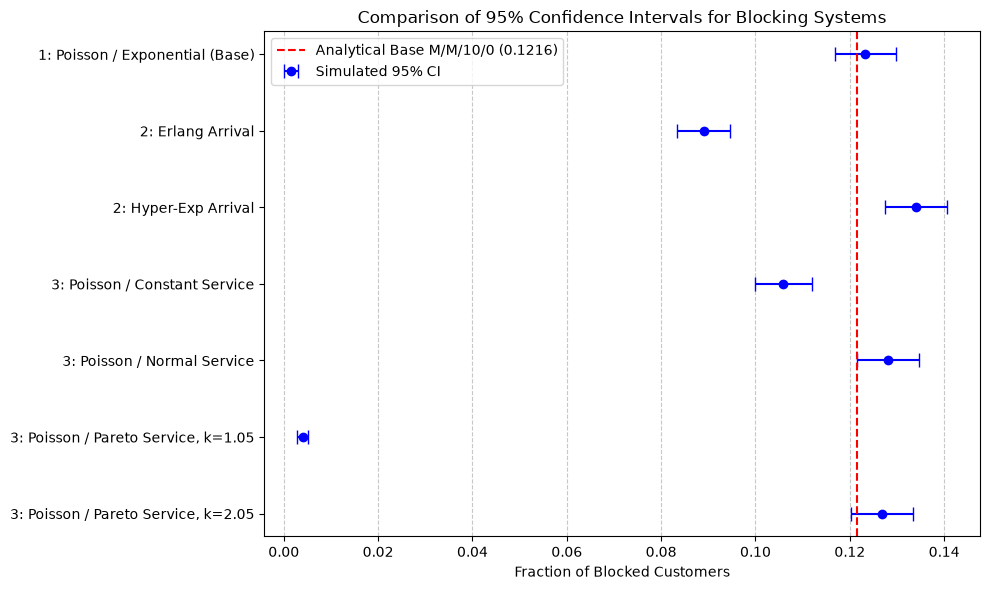

In [42]:
import matplotlib.pyplot as plt

# 1. Define the data extracted from the simulation notebook outputs
experiments = [
    "1: Poisson / Exponential (Base)",
    "2: Erlang Arrival",
    "2: Hyper-Exp Arrival",
    "3: Poisson / Constant Service",
    "3: Poisson / Normal Service",
    "3: Poisson / Pareto Service, k=1.05",
    "3: Poisson / Pareto Service, k=2.05"
]

# Mean blocked fractions
means = [0.1233, 0.0890, 0.1341, 0.1059, 0.1281, 0.004, 0.1268]


# 95% Confidence Interval bounds
lower_bounds = [0.1168, 0.0834, 0.1274, 0.0998, 0.1215, 0.0027628688670961353, 0.12027812363490382]
upper_bounds = [0.1297, 0.0945, 0.1407, 0.1119, 0.1346, 0.005237131132903865, 0.13332187636509615]  

# Calculate the error margins for plotting
error_lower = [m - l for m, l in zip(means, lower_bounds)]
error_upper = [u - m for m, u in zip(means, upper_bounds)]
errors = [error_lower, error_upper]

# 2. Plotting the Confidence Intervals
plt.figure(figsize=(10, 6))
plt.errorbar(means, range(len(experiments)), xerr=errors, fmt='o', color='b', capsize=5, label='Simulated 95% CI')

# Add a vertical line for the analytical solution from Part 1
analytical_mean = 0.1216
plt.axvline(x=analytical_mean, color='r', linestyle='--', label=f'Analytical Base M/M/10/0 ({analytical_mean})')

# Formatting
plt.yticks(range(len(experiments)), experiments)
plt.xlabel("Fraction of Blocked Customers")
plt.title("Comparison of 95% Confidence Intervals for Blocking Systems")
plt.gca().invert_yaxis()  # Highest experiment at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()

# Exercise 7

## Exercise 7.1

Implement simulated annealing for the travelling salesman. As proposal, permute two random stations on the route. As cooling scheme, you can use e.g. Tk = 1/√1 + k. or Tk = − log(k + 1), feel free to experiment with different choices. The route must end where it started. Initialise with a random permutation of stations.

In [43]:
def euclidean_distance(p, q):
    """Calculates the Euclidean distance between two points p and q.

    Args:
        p (float): The x and y coordinates of the first point.
        q (float): The x and y coordinates of the second point.

    Returns:
        float: The Euclidean distance between the two points.
    """
    p1, p2 = p
    q1, q2 = q
    return math.sqrt((q1 - p1)**2 + (q2 - p2)**2)

def total_distance_cost(route, positions):
    """Calculates the total distance cost of a given route based on the positions of the cities.

    Args:
        route (list): A list of indices representing the order of cities in the route.
        positions (list): A list of tuples representing the x and y coordinates of each city.

    Returns:
        float: The total distance cost of the route.
    """
    dist = sum(euclidean_distance(positions[route[i]], positions[route[i+1]]) for i in range(len(route)-1))
    # Add the distance from the final city back to the first city
    dist += euclidean_distance(positions[route[-1]], positions[route[0]])
    return dist


def sqrt_cooling_schedule(initial_temp, iteration, cooling_rate=0.01):
    """Calculates the cooling schedule for simulated annealing.

    Args:
        initial_temp (float): The initial temperature.
        iteration (int): The current iteration number.
        cooling_rate (float): The rate at which the temperature decreases.
    
    Returns:
        float: The current temperature based on the cooling schedule.

    """

    return 1 / math.sqrt(1 + iteration)

def geometric_cooling_schedule(initial_temp, iteration, cooling_rate=0.01):
    """Calculates the geometric cooling schedule for simulated annealing.

    Args:
        initial_temp (float): The initial temperature.
        iteration (int): The current iteration number.
        cooling_rate (float): The rate at which the temperature decreases.

    Returns:
        float: The current temperature based on the geometric cooling schedule.
    """
    return initial_temp * (cooling_rate ** iteration)

def logarithmic_cooling_schedule(initial_temp, iteration, cooling_rate=0.01):
    """Calculates the logarithmic cooling schedule for simulated annealing.

    Args:
        initial_temp (float): The initial temperature.
        iteration (int): The current iteration number.
        cooling_rate (float): The rate at which the temperature decreases.
    Returns:
        float: The current temperature based on the logarithmic cooling schedule.
    """
    return initial_temp / math.log(2 + iteration)

def swap_two_cities(route):
    """Swaps two cities in the given route.

    Args:
        route (list): A list of indices representing the order of cities in the route.

    Returns:
        list: A new route with two cities swapped.
    """
    new_route = route.copy()
    i, j = random.sample(range(1, len(route)), 2)
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route


def two_opt(current_route):
    """Performs a 2-opt swap on the given route.

    Args:
        current_route (list): A list of indices representing the order of cities in the route.

    Returns:
        list: A new route with a segment reversed.
    """
    i, j = sorted(random.sample(range(1, len(current_route)), 2))
    return current_route[:i] + current_route[i:j+1][::-1] + current_route[j+1:]

In [44]:
def simulated_annealing_tsp(positions, num_iterations, cooling_scheme=sqrt_cooling_schedule, initial_temp=1, cooling_rate=0.01, permutation_function=swap_two_cities):
    """Solves the Traveling Salesman Problem using the Simulated Annealing algorithm.

    Args:
        positions (list): A list of tuples representing the x and y coordinates of each city.
        num_iterations (int): The number of iterations for the simulated annealing algorithm.
        cooling_scheme (function): The cooling schedule function.
        initial_temp (float): The initial temperature for the cooling schedule.
        cooling_rate (float): The rate at which the temperature decreases for the cooling schedule.

    Returns:
        tuple: A tuple containing the best route (list of indices) and the best distance (float).
    """

    current_route = list(np.random.permutation(len(positions)))
    best_route = list(current_route)
    best_distance = total_distance_cost(best_route, positions)

    # cooling scheme 1 / sqrt(1 + k)

    for k in range(num_iterations):

        # temperature = decreasing function of time or iteration number.
        Tk = cooling_scheme(initial_temp, k, cooling_rate)
        Tk = max(Tk, 1e-10) 

        # Permute two random stations on the route
        new_route = permutation_function(current_route)
        
        # find state X and canidate Y
        Ux = total_distance_cost(current_route, positions)
        Uy = total_distance_cost(new_route, positions)
       
        # The Metropolis-Hastings acceptance criterion
        if Uy - Ux < 0 or random.random() < math.exp((-(Uy - Ux)) / Tk):
            current_route = new_route
            Ux = Uy

        # finding best distance
        if Ux < best_distance:
            best_route = list(current_route)
            best_distance = Ux

    return best_route, best_distance

### (a)

Have input be positions in the plane of the n stations.
Let the cost of going i 7 → j be the Euclidian distance
between station i and j.
Plot the resulting route in the plane.
Debug with stations on a circle.

In [45]:
points_on_circle = 10

# defines position as a cirkel
positions = [(math.cos(2*math.pi*i/points_on_circle), math.sin(2*math.pi*i/points_on_circle)) for i in range(points_on_circle)]

num_iterations = 1000

In [46]:
best_route, best_distance = simulated_annealing_tsp(positions, num_iterations, cooling_scheme=sqrt_cooling_schedule, initial_temp=100, cooling_rate=0.01, permutation_function=two_opt)

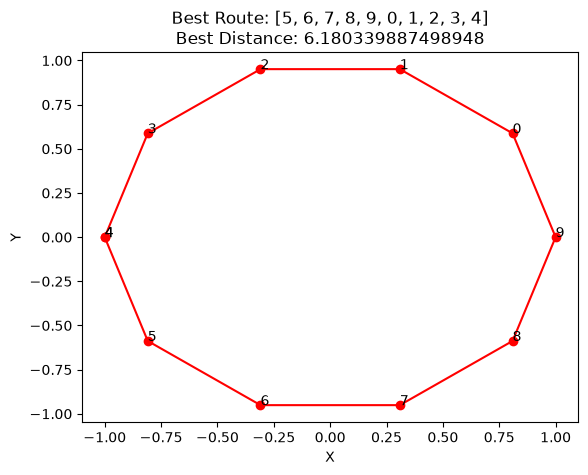

In [47]:
x = [positions[i][0] for i in best_route]
y = [positions[j][1] for j in best_route]
x.append(x[0]) 
y.append(y[0])
plt.plot(x, y, 'ro-')
best_route = [int(x) for x in best_route]
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.text(xi, yi, str(int(best_route[i-1])), color='black')

plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Best Route: {best_route}\nBest Distance: {best_distance}')
plt.show()

### (b)

Then modify your progamme to work with costs directly
and apply it to the cost matrix from the course homepage.

In [48]:
cost_matrix = pd.read_csv("cost.csv", header=None).values

In [49]:
def total_distance_cost(route, cost):
    """Modified version of total_distance_cost to use a cost matrix instead of positions.

    Args:
        route (list): A list of indices representing the order of cities in the route.
        cost (numpy.ndarray): A 2D array representing the cost matrix.

    Returns:
        float: The total cost of the route.
    """
    return sum(cost[route[i]][route[i+1]] for i in range(len(route)-1)) + cost[route[-1]][route[0]]  # Add the cost to return to the starting city

In [50]:
num_iterations = 100000
cheapest_route, best_cost = simulated_annealing_tsp(cost_matrix, num_iterations, cooling_scheme=logarithmic_cooling_schedule, initial_temp=100, cooling_rate=0.1, permutation_function=two_opt)

In [51]:
# print the best route and its cost for each of the cooling schemes and permutation functions
print(f"Best route: {cheapest_route}")
print(f"Best cost: {best_cost}")


Best route: [np.int64(5), np.int64(0), np.int64(3), np.int64(12), np.int64(2), np.int64(10), np.int64(19), np.int64(6), np.int64(17), np.int64(16), np.int64(4), np.int64(7), np.int64(15), np.int64(9), np.int64(18), np.int64(14), np.int64(1), np.int64(8), np.int64(13), np.int64(11)]
Best cost: 790


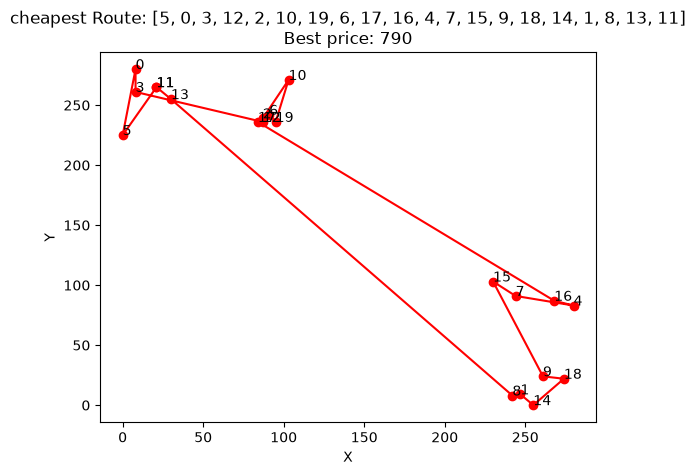

In [52]:
x = [cost_matrix[i][0] for i in cheapest_route]
y = [cost_matrix[j][1] for j in cheapest_route]
x.append(x[0]) 
y.append(y[0])
plt.plot(x, y, 'ro-')
cheapest_route = [int(x) for x in cheapest_route]
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.text(xi, yi, str(cheapest_route[i-1]), color='black')

plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'cheapest Route: {cheapest_route}\nBest price: {best_cost}')
plt.show()

In [53]:
iterations = 100000
start_temp = 100.0

proposals = {
    "Swap": swap_two_cities,
    "2-Opt": two_opt
}

schedules = {
    "Geometric": lambda t, k, s: geometric_cooling_schedule(t, k, 0.1),
    "Logarithmic": lambda t, k, s: logarithmic_cooling_schedule(t, k, 0.1),
    "Sqrt": lambda t, k, s: sqrt_cooling_schedule(t, k, 0.1)
}

print(f"{'Proposal Mechanism':<20} | {'Cooling Schedule':<20} | {'Best Cost'}")
print("-" * 60)

for prop_name, prop_func in proposals.items():
    for cool_name, cool_func in schedules.items():
        # Re-seed inside the loop so each scheme starts with the exact same initial random route
        _, best_cost = simulated_annealing_tsp(
            positions=cost_matrix,
            num_iterations=iterations,
            permutation_function=prop_func,
            cooling_scheme=cool_func,
            initial_temp=start_temp
        )
        print(f"{prop_name:<20} | {cool_name:<20} | {best_cost}")

Proposal Mechanism   | Cooling Schedule     | Best Cost
------------------------------------------------------------
Swap                 | Geometric            | 1291
Swap                 | Logarithmic          | 1101
Swap                 | Sqrt                 | 1024
2-Opt                | Geometric            | 819
2-Opt                | Logarithmic          | 786
2-Opt                | Sqrt                 | 818
